### Architecture
In this experiment, a Swin Transformer model is trained on image data, while a GBDT model is trained on metadata using 70% of the training set. Five-fold cross-validation is applied, and out-of-fold (OOF) predictions are collected from both models. These OOF predictions are then stacked to form the input for a second-stage SVR meta-learner, which is trained to produce the final predictions.

During inference, the test data is evaluated by all five fold-specific models of each backbone. The predictions from the five folds are averaged, resulting in two features: swin_mean and gbdt_mean. The final predictions are obtained by feeding these averaged features into the second-stage SVR model.


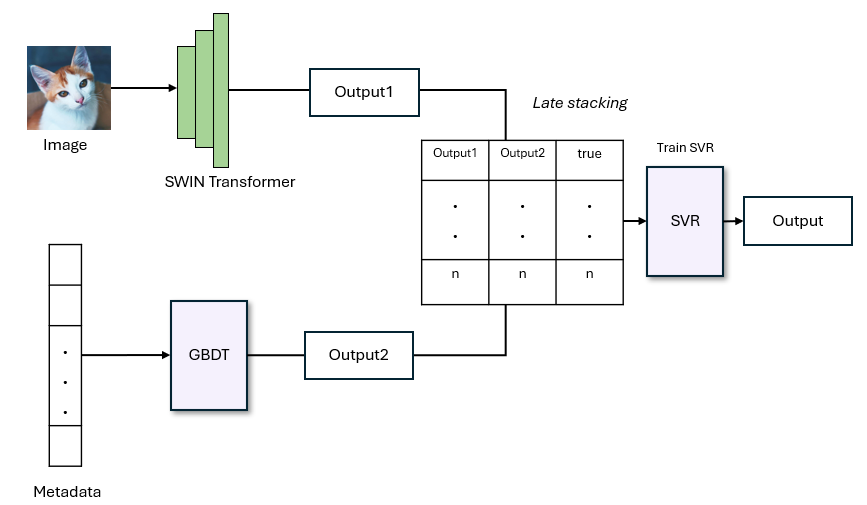

### Analysis

The 2nd‑stage SVR gives only a marginal global RMSE change vs the 5‑fold early‑fusion ensemble and is worse, so prediction‑level meta‑learning is not extracting much new signal; this indicates the SWIN and tabular models’ errors are in the same region (extreme high). 


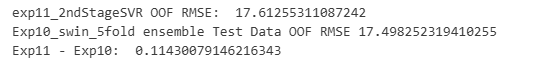

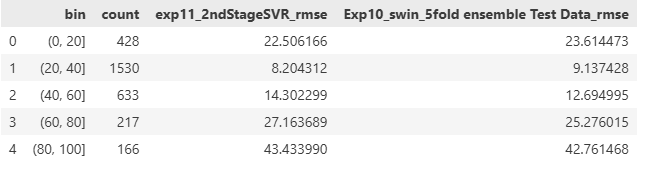



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

In [3]:

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold, StratifiedShuffleSplit
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageTabDataset
from src.models import FeatureConcatFusionNet

main_folder = ".."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "exp11")

#since the experiment has the same configuration as exp3 except the testing data split, so all the configs are copied from exp3
df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp3"]
cfg["name"] = "exp11_SWIN_GBDT_stacking"
TARGET = "Pawpularity"

# ---------- STRATIFIED 70/30 SPLIT ----------
df["bins"] = pd.qcut(df[TARGET], q=10, labels=False, duplicates='drop')


splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=cfg["seed"]
)

for train_idx, test_idx in splitter.split(df, df["bins"]):
    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

train_df = train_df.drop(columns=["bins"])
test_df  = test_df.drop(columns=["bins"])

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

# tabular columns remain same
tab_cols = [c for c in df.columns if c not in ["Id", TARGET, "bins"]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train size: (6938, 14)
Test size: (2974, 14)


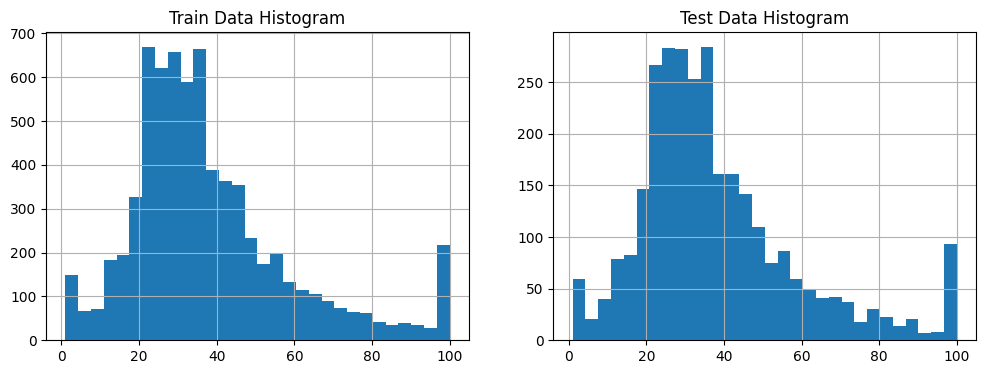

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
train_df[TARGET].hist(bins=30)
plt.title("Train Data Histogram")

plt.subplot(1,2,2)
test_df[TARGET].hist(bins=30)
plt.title("Test Data Histogram")
plt.show()


In [6]:

#  5-Fold CV on 70% train data
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])

oof_pred = np.zeros(len(train_df))
oof_true = train_df[TARGET].values
fold_index = np.full(len(train_df), -1, dtype=int)
fold_rmse = []

start_all = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(train_df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")

    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    val_df   = train_df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=tr_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")

# ---------- OOF stats ----------
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)

print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": train_df["Id"],
    "fold": fold_index,
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)

oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)

with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")




=== exp11_SWIN_GBDT_stacking: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[BCE]: Loss=0.6517 | ValRMSE: 18.3474
Epoch 2/10 | Fold 1 | Train[BCE]: Loss=0.6408 | ValRMSE: 18.5560
Epoch 3/10 | Fold 1 | Train[BCE]: Loss=0.6329 | ValRMSE: 18.5845
Epoch 4/10 | Fold 1 | Train[BCE]: Loss=0.6241 | ValRMSE: 18.9175
Epoch 5/10 | Fold 1 | Train[BCE]: Loss=0.6141 | ValRMSE: 19.4023
Epoch 6/10 | Fold 1 | Train[BCE]: Loss=0.6054 | ValRMSE: 19.6184
Early stopping at epoch 6
Fold 1 best RMSE: 18.3474

=== exp11_SWIN_GBDT_stacking: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[BCE]: Loss=0.6499 | ValRMSE: 18.6390
Epoch 2/10 | Fold 2 | Train[BCE]: Loss=0.6384 | ValRMSE: 18.7174
Epoch 3/10 | Fold 2 | Train[BCE]: Loss=0.6314 | ValRMSE: 18.6925
Epoch 4/10 | Fold 2 | Train[BCE]: Loss=0.6218 | ValRMSE: 19.2139
Epoch 5/10 | Fold 2 | Train[BCE]: Loss=0.6117 | ValRMSE: 19.3066
Epoch 6/10 | Fold 2 | Train[BCE]: Loss=0.6028 | ValRMSE: 19.1624
Early stopping at epoch 6
Fold 2 best RMSE: 18.6390

=== exp11_SWIN_GBDT_stacking: F

In [26]:
from lightgbm import LGBMRegressor  
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold
import joblib

# -----------------------------------------
# MATCH SWIN OOF STRUCTURE
# -----------------------------------------
gbdt_oof = np.zeros(len(train_df))
gbdt_rmse_folds = []
fold_index = np.full(len(train_df), -1, dtype=int)

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])

for fold, (train_idx, val_idx) in enumerate(kf.split(train_df), start=1):

    tr_df = train_df.iloc[train_idx].reset_index(drop=True)
    val_df = train_df.iloc[val_idx].reset_index(drop=True)

    model_gbdt = LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.01,
        num_leaves=128,
        max_depth=20,
        min_data_in_leaf=50,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        lambda_l1=0.1,
        lambda_l2=0.1,
        random_state=cfg["seed"],
        metric="rmse",
        verbose=-1,
    )

    model_gbdt.fit(
        tr_df[tab_cols], tr_df[TARGET],
        eval_set=[(val_df[tab_cols], val_df[TARGET])],
        eval_metric="rmse",
    )

    # ----------------------------
    # SAVE MODEL FOR THIS FOLD
    # ----------------------------
    joblib.dump(
        model_gbdt,
        os.path.join(out_dir, f"gbdt_fold{fold}.pkl")
    )

    preds = model_gbdt.predict(val_df[tab_cols])

    gbdt_oof[val_idx] = preds
    fold_index[val_idx] = fold

    fold_rmse = root_mean_squared_error(val_df[TARGET], preds)
    gbdt_rmse_folds.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

# -----------------------------------------
# OVERALL RESULTS
# -----------------------------------------
gbdt_rmse = root_mean_squared_error(train_df[TARGET], gbdt_oof)

print("\n======== FINAL RESULTS ========")
print(f"GBDT OOF RMSE: {gbdt_rmse:.4f}")
print(f"Fold RMSEs: {gbdt_rmse_folds}")
print(f"Mean: {np.mean(gbdt_rmse_folds):.4f}, Std: {np.std(gbdt_rmse_folds):.4f}")

# -----------------------------------------
# SAVE OOF RESULTS — SAME FORMAT AS SWIN
# -----------------------------------------
gbdt_oof_df = pd.DataFrame({
    "Id": train_df["Id"],
    "fold": fold_index,
    "ytrue": train_df[TARGET].values,
    "oof_pred": gbdt_oof,
})

gbdt_oof_df["abs_err"] = (gbdt_oof_df["ytrue"] - gbdt_oof_df["oof_pred"]).abs()

gbdt_oof_df.to_csv(os.path.join(out_dir, "oof_detail_gbdt.csv"), index=False)

# save top errors also
gbdt_oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors_gbdt.csv"),
    index=False
)


Fold 1 RMSE: 20.5861
Fold 2 RMSE: 21.3017
Fold 3 RMSE: 19.9597
Fold 4 RMSE: 20.8896
Fold 5 RMSE: 20.8531

======== FINAL RESULTS ========
GBDT OOF RMSE: 20.7227
Fold RMSEs: [20.58611804780522, 21.30173290675153, 19.95969187517843, 20.889632053652747, 20.853099065083036]
Mean: 20.7181, Std: 0.4429


In [4]:
swin_oof_preds = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))  #
swin_oof_preds.head()

,Id,fold,ytrue,oof_pred,abs_err
0,623fe812055f540f1a5c62ecb8557ae4,3,23,33.005630,10.005630
1,6189f7acb20a7895203bc6ca53414447,4,69,46.279449,22.720551
2,ea85e9bf1ed9e6472e35288c4fa18187,4,24,34.897587,10.897587
3,2f155ce45d46b1e6e3cb1dd9126d9927,5,18,24.765980,6.765980
4,90b389b5a1967598d2665ed46a75003a,5,37,51.286591,14.286591


In [5]:
gbdt_oof_preds = pd.read_csv(os.path.join(out_dir, "oof_detail_gbdt.csv"))  #
gbdt_oof_preds.head()

,Id,fold,ytrue,oof_pred,abs_err
0,623fe812055f540f1a5c62ecb8557ae4,3,23,37.413626,14.413626
1,6189f7acb20a7895203bc6ca53414447,4,69,41.057852,27.942148
2,ea85e9bf1ed9e6472e35288c4fa18187,4,24,33.062341,9.062341
3,2f155ce45d46b1e6e3cb1dd9126d9927,5,18,36.813419,18.813419
4,90b389b5a1967598d2665ed46a75003a,5,37,35.822181,1.177819


In [6]:
swin_map = swin_oof_preds[["Id", "fold"]].sort_values("Id").reset_index(drop=True)
gbdt_map = gbdt_oof_preds[["Id", "fold"]].sort_values("Id").reset_index(drop=True)

assert set(swin_map["Id"]) == set(gbdt_map["Id"]), "IDs differ!"
assert swin_map.equals(gbdt_map), "Fold assignment differs!"

print("IDs and fold assignments match.")





IDs and fold assignments match.


In [7]:
swin_targets = swin_oof_preds[["Id", "ytrue"]].sort_values("Id").reset_index(drop=True)
gbdt_targets = gbdt_oof_preds[["Id", "ytrue"]].sort_values("Id").reset_index(drop=True)

assert swin_targets.equals(gbdt_targets), "TARGET values differ!"

print("Targets  match.")

Targets  match.


In [8]:
# Merge OOF preds on id + fold
oof_merged = swin_oof_preds.merge(
    gbdt_oof_preds,
    on=["Id", "fold", "ytrue"],
    suffixes=("_swin", "_gbdt")
)

oof_merged.head()
print(oof_merged.shape)
oof_merged.to_csv(
    os.path.join(out_dir, "oof_merged_swin_gbdt.csv"), index=False)

(6938, 7)


In [9]:
oof_merged.head()

,Id,fold,ytrue,oof_pred_swin,abs_err_swin,oof_pred_gbdt,abs_err_gbdt
0,623fe812055f540f1a5c62ecb8557ae4,3,23,33.005630,10.005630,37.413626,14.413626
1,6189f7acb20a7895203bc6ca53414447,4,69,46.279449,22.720551,41.057852,27.942148
2,ea85e9bf1ed9e6472e35288c4fa18187,4,24,34.897587,10.897587,33.062341,9.062341
3,2f155ce45d46b1e6e3cb1dd9126d9927,5,18,24.765980,6.765980,36.813419,18.813419
4,90b389b5a1967598d2665ed46a75003a,5,37,51.286591,14.286591,35.822181,1.177819


### 2nd stage meta learner training

In [60]:
from src.utils import train_meta_learner_oof
model, rmse, feats = train_meta_learner_oof(
    oof_merged,
    model_name="lgbm",
    feature_prefix="oof_",
    y_col="ytrue",
)
meta_model_path = os.path.join(out_dir, "meta_model_lgbm.pkl")
joblib.dump({
    "model": model,
    "features": feats,
}, meta_model_path)


['../outputs/exp11/meta_model_lgbm.pkl']

In [62]:

model, rmse, feats = train_meta_learner_oof(
    oof_merged,
    model_name="xgb",
    feature_prefix="oof_",
    y_col="ytrue",
)
meta_model_path = os.path.join(out_dir, "meta_model_xgb.pkl")
joblib.dump({
    "model": model,
    "features": feats,
}, meta_model_path)



['../outputs/exp11/meta_model_xgb.pkl']

In [63]:
from src.utils import train_meta_learner_oof
model, rmse, feats = train_meta_learner_oof(
    oof_merged,
    model_name="svr_gpu",
    feature_prefix="oof_",
    y_col="ytrue",
)
meta_model_path = os.path.join(out_dir, "meta_model_svr_gpu.pkl")
joblib.dump({
    "model": model,
    "features": feats,
}, meta_model_path)



['../outputs/exp11/meta_model_svr_gpu.pkl']

In [36]:
test_df.head()

,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,eaa7d909c1f3fac946be7acc768ecc3e,0,1,1,0,0,0,0,0,0,0,0,0,99
1,b8ceb2877086b0db683ed28d0dbf6b3a,0,0,0,1,0,0,0,0,0,0,0,0,22
2,232193022ce0e9a7433f76e543992000,0,1,1,1,0,0,0,0,0,0,0,0,40
3,1d3dd097162e7022fca80feb7882c260,0,1,1,1,0,1,0,0,0,0,0,0,24
4,a4cfe1ab4ef8e23451c250660e09de9a,0,1,1,1,0,0,0,0,0,0,0,0,18


### 2nd stage meta learner inference on test data

> ### 1. LGBM

In [10]:
from src.inference import infer_meta_ensemble
final_pred, meta_test_df,rmse,out_df = infer_meta_ensemble(
    test_df=test_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    tab_cols=tab_cols,
    workers=8,
    metaStage_model="meta_model_lgbm.pkl"
)


Swin inference done.
GBDT inference done.


In [12]:
print("2nd stage meta learner lgbm test RMSE: ", root_mean_squared_error(out_df["ytrue"], out_df["pred_2ndStage_gbdt"]))
print("5 folds average swin test rmse without metadata: ", root_mean_squared_error(out_df["ytrue"], out_df["pred_swin_mean"]))
print("5 folds average gbdt test rmse: ", root_mean_squared_error(out_df["ytrue"], out_df["pred_gbdt_mean"]))

2nd stage meta learner lgbm test RMSE:  18.356626760013448
5 folds average swin test rmse without metadata:  17.408477783203125
5 folds average gbdt test rmse:  20.490629524783053


> ### 2. xgboost

In [13]:
final_pred, meta_test_df,rmse,out_df = infer_meta_ensemble(
    test_df=test_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    tab_cols=tab_cols,
    workers=8,
    metaStage_model="meta_model_xgb.pkl"
)

Swin inference done.
GBDT inference done.


In [14]:
print("2nd stage meta learner xgboost test RMSE: ", root_mean_squared_error(out_df["ytrue"], out_df["pred_2ndStage_gbdt"]))
print("5 folds average swin test rmse without metadata: ", root_mean_squared_error(out_df["ytrue"], out_df["pred_swin_mean"]))
print("5 folds average gbdt test rmse: ", root_mean_squared_error(out_df["ytrue"], out_df["pred_gbdt_mean"]))

2nd stage meta learner xgboost test RMSE:  18.396116256713867
5 folds average swin test rmse without metadata:  17.408477783203125
5 folds average gbdt test rmse:  20.490629524783053


> ### 3. SVR

In [15]:
final_pred, meta_test_df,rmse,out_df = infer_meta_ensemble(
    test_df=test_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    tab_cols=tab_cols,
    workers=8,
    metaStage_model="meta_model_svr_gpu.pkl"
)

Swin inference done.
GBDT inference done.


In [16]:
print("2nd stage meta learner SVR test RMSE: ", root_mean_squared_error(out_df["ytrue"], out_df["pred_2ndStage_gbdt"]))
print("5 folds average swin test rmse without metadata: ", root_mean_squared_error(out_df["ytrue"], out_df["pred_swin_mean"]))
print("5 folds average gbdt test rmse: ", root_mean_squared_error(out_df["ytrue"], out_df["pred_gbdt_mean"]))

2nd stage meta learner SVR test RMSE:  17.61255311087242
5 folds average swin test rmse without metadata:  17.408477783203125
5 folds average gbdt test rmse:  20.490629524783053


In [37]:
out_df = out_df.rename(columns={"pred_2ndStage_gbdt":"pred_2ndStageSVR"})
out_df.head()

,Id,ytrue,pred_swin_fold1,pred_gbdt_fold1,pred_swin_fold2,pred_gbdt_fold2,pred_swin_fold3,pred_gbdt_fold3,pred_swin_fold4,pred_gbdt_fold4,pred_swin_fold5,pred_gbdt_fold5,pred_swin_mean,pred_gbdt_mean,pred_2ndStageSVR
0,eaa7d909c1f3fac946be7acc768ecc3e,99,58.520294,37.618458,61.060493,37.343576,66.361794,37.247615,54.308628,37.004129,74.726913,37.780851,62.995625,37.398926,68.941700
1,b8ceb2877086b0db683ed28d0dbf6b3a,22,33.827953,35.568848,32.640312,37.248023,28.764832,37.046448,30.672894,36.623697,24.479975,36.826521,30.077194,36.662707,28.601216
2,232193022ce0e9a7433f76e543992000,40,31.815355,38.554092,29.010981,37.865739,31.803873,38.503059,30.844477,38.307304,30.988131,38.067529,30.892563,38.259545,29.704249
3,1d3dd097162e7022fca80feb7882c260,24,27.232515,40.406705,22.477768,39.926249,26.842981,40.408441,27.148661,40.468090,23.760128,41.066094,25.492411,40.455116,26.339830
4,a4cfe1ab4ef8e23451c250660e09de9a,18,34.043720,38.554092,21.185122,37.865739,19.918797,38.503059,20.866934,38.307304,20.124203,38.067529,23.227757,38.259545,25.237355


In [38]:
out_path = os.path.join(out_dir, "exp11_meta_learner_svr_test_pred.csv")
out_df.to_csv(out_path, index=False)


In [39]:
test_df_pred = pd.read_csv(os.path.join(out_dir, "exp11_meta_learner_svr_test_pred.csv"))

In [40]:
test_df_pred["abs_err"]= (test_df_pred["ytrue"] - test_df_pred["pred_2ndStageSVR"]).abs()

In [20]:
test_err_df = test_df_pred.sort_values("abs_err", ascending=False)
test_err_df.to_csv(os.path.join(out_dir, "exp11_2ndstage_top_errors.csv"), index=False)

In [43]:
test_df_top_errors = pd.read_csv(os.path.join(out_dir, "exp11_2ndstage_top_errors.csv")).head(50).rename(columns={"pred_2ndStage_gbdt":"pred_2ndStageSVR"})
test_df_top_errors[["Id", "pred_2ndStageSVR","ytrue", "abs_err"]].head()

,Id,pred_2ndStageSVR,ytrue,abs_err
0,9a76b2c5d66bc2140b53ca89a296442d,82.531490,8,74.531490
1,b2a389311b683a90c3c9763540a86bab,75.858075,2,73.858075
2,4435d6f98ad72782ca0cf61f946b016d,27.799962,100,72.200038
3,deb8d1618d0cdc2a78c8198b882ebb2b,28.489463,100,71.510537
4,941e532a21f7edb21766e88a15e588cb,30.071209,100,69.928791


In [44]:
# exp 10 for comparison
exp10_df = pd.read_csv(os.path.join("../outputs/exp10", "test_cv_df.csv"))
exp10_df.head()

,Id,fold,ytrue,fold1_pred,fold2_pred,fold3_pred,fold4_pred,fold5_pred,avg,abs_err
0,eaa7d909c1f3fac946be7acc768ecc3e,-1,99,55.151535,59.174747,68.099740,58.098106,55.161415,59.137108,39.862892
1,b8ceb2877086b0db683ed28d0dbf6b3a,-1,22,31.511005,24.815277,29.273453,22.484533,24.413065,26.499466,4.499466
2,232193022ce0e9a7433f76e543992000,-1,40,31.039825,33.525578,27.875154,29.641380,27.188390,29.854065,10.145935
3,1d3dd097162e7022fca80feb7882c260,-1,24,23.642958,26.518717,22.174925,20.199024,25.934210,23.693968,0.306032
4,a4cfe1ab4ef8e23451c250660e09de9a,-1,18,27.053818,29.786366,22.102282,21.812930,21.930126,24.537104,6.537104


In [45]:
# exp 11, current experiment
test_df_pred.head()

,Id,ytrue,pred_swin_fold1,pred_gbdt_fold1,pred_swin_fold2,pred_gbdt_fold2,pred_swin_fold3,pred_gbdt_fold3,pred_swin_fold4,pred_gbdt_fold4,pred_swin_fold5,pred_gbdt_fold5,pred_swin_mean,pred_gbdt_mean,pred_2ndStageSVR,abs_err
0,eaa7d909c1f3fac946be7acc768ecc3e,99,58.520294,37.618458,61.060493,37.343576,66.361790,37.247615,54.308628,37.004129,74.726910,37.780851,62.995625,37.398926,68.941700,30.058300
1,b8ceb2877086b0db683ed28d0dbf6b3a,22,33.827953,35.568848,32.640312,37.248023,28.764832,37.046448,30.672894,36.623697,24.479975,36.826521,30.077194,36.662707,28.601216,6.601216
2,232193022ce0e9a7433f76e543992000,40,31.815355,38.554092,29.010980,37.865739,31.803873,38.503059,30.844477,38.307304,30.988130,38.067529,30.892563,38.259545,29.704249,10.295751
3,1d3dd097162e7022fca80feb7882c260,24,27.232515,40.406705,22.477768,39.926249,26.842981,40.408441,27.148660,40.468090,23.760128,41.066094,25.492410,40.455116,26.339830,2.339830
4,a4cfe1ab4ef8e23451c250660e09de9a,18,34.043720,38.554092,21.185122,37.865739,19.918797,38.503059,20.866934,38.307304,20.124203,38.067529,23.227757,38.259545,25.237355,7.237355


In [46]:
merged = test_df_pred.merge(
    exp10_df[["Id", "avg"]],   # only Id and avg from exp10
    on="Id",
    how="left",
)

# optional: rename avg column to something clearer
merged = merged.rename(columns={"avg": "exp10_cv_ensemble", "pred_2ndStageSVR": "exp11_2ndStageSVR"})



In [69]:
merged.to_csv(os.path.join(out_dir, "exp11_exp10_merge.csv"), index=False)

In [47]:
merged[["Id", "exp10_cv_ensemble", "exp11_2ndStageSVR","ytrue"]].head()

,Id,exp10_cv_ensemble,exp11_2ndStageSVR,ytrue
0,eaa7d909c1f3fac946be7acc768ecc3e,59.137108,68.941700,99
1,b8ceb2877086b0db683ed28d0dbf6b3a,26.499466,28.601216,22
2,232193022ce0e9a7433f76e543992000,29.854065,29.704249,40
3,1d3dd097162e7022fca80feb7882c260,23.693968,26.339830,24
4,a4cfe1ab4ef8e23451c250660e09de9a,24.537104,25.237355,18


exp11_2ndStageSVR OOF RMSE: 17.6126
Exp10_swin_5fold ensemble Test Data OOF RMSE: 17.4983


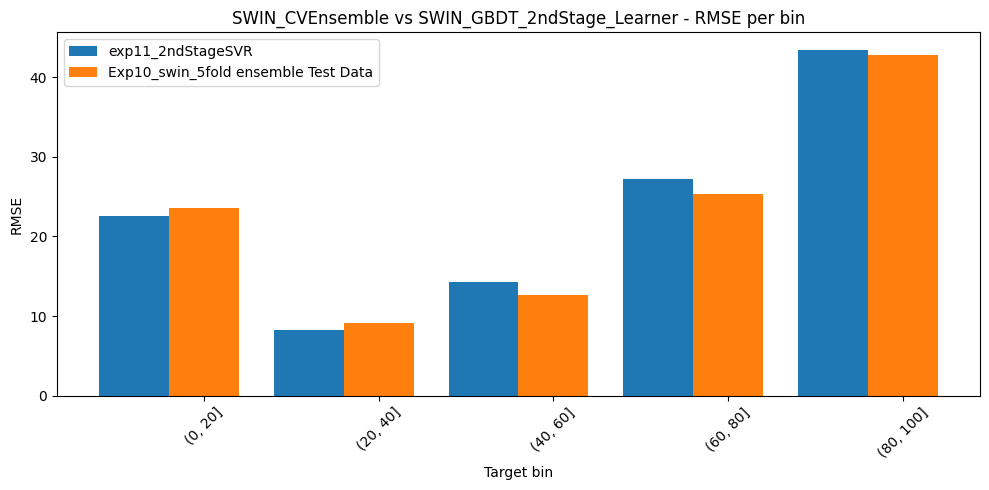

In [61]:
bins = [0, 20, 40, 60, 80, 100]
from src.plot import compare_oof_by_bins_multi

summary, overall = compare_oof_by_bins_multi(
    merged,
    bins=bins,
    y_col="ytrue",
    pred_cols={
        "exp11_2ndStageSVR": "exp11_2ndStageSVR",
        "Exp10_swin_5fold ensemble Test Data": "exp10_cv_ensemble",
    },
    title_prefix="SWIN_CVEnsemble vs SWIN_GBDT_2ndStage_Learner"
)

In [66]:
exp11_rmse = overall["exp11_2ndStageSVR"]
exp10_rmse = overall["Exp10_swin_5fold ensemble Test Data"]

In [68]:
print("exp11_2ndStageSVR OOF RMSE: ",  exp11_rmse)
print("Exp10_swin_5fold ensemble Test Data OOF RMSE",exp10_rmse)
print("Exp11 - Exp10: ", exp11_rmse-exp10_rmse)

exp11_2ndStageSVR OOF RMSE:  17.61255311087242
Exp10_swin_5fold ensemble Test Data OOF RMSE 17.498252319410255
Exp11 - Exp10:  0.11430079146216343


In [50]:
summary.rename(columns={"exp11_2ndStage_gbdt_rmse":"exp11_2ndStageSVR_rmse"}).head()

,bin,count,exp11_2ndStageSVR_rmse,Exp10_swin_5fold ensemble Test Data_rmse
0,"(0, 20]",428,22.506166,23.614473
1,"(20, 40]",1530,8.204312,9.137428
2,"(40, 60]",633,14.302299,12.694995
3,"(60, 80]",217,27.163689,25.276015
4,"(80, 100]",166,43.433990,42.761468


In [53]:
test_err_df = test_err_df.rename(columns={"pred_2ndStage_gbdt":"pred_2ndStageSVR"})

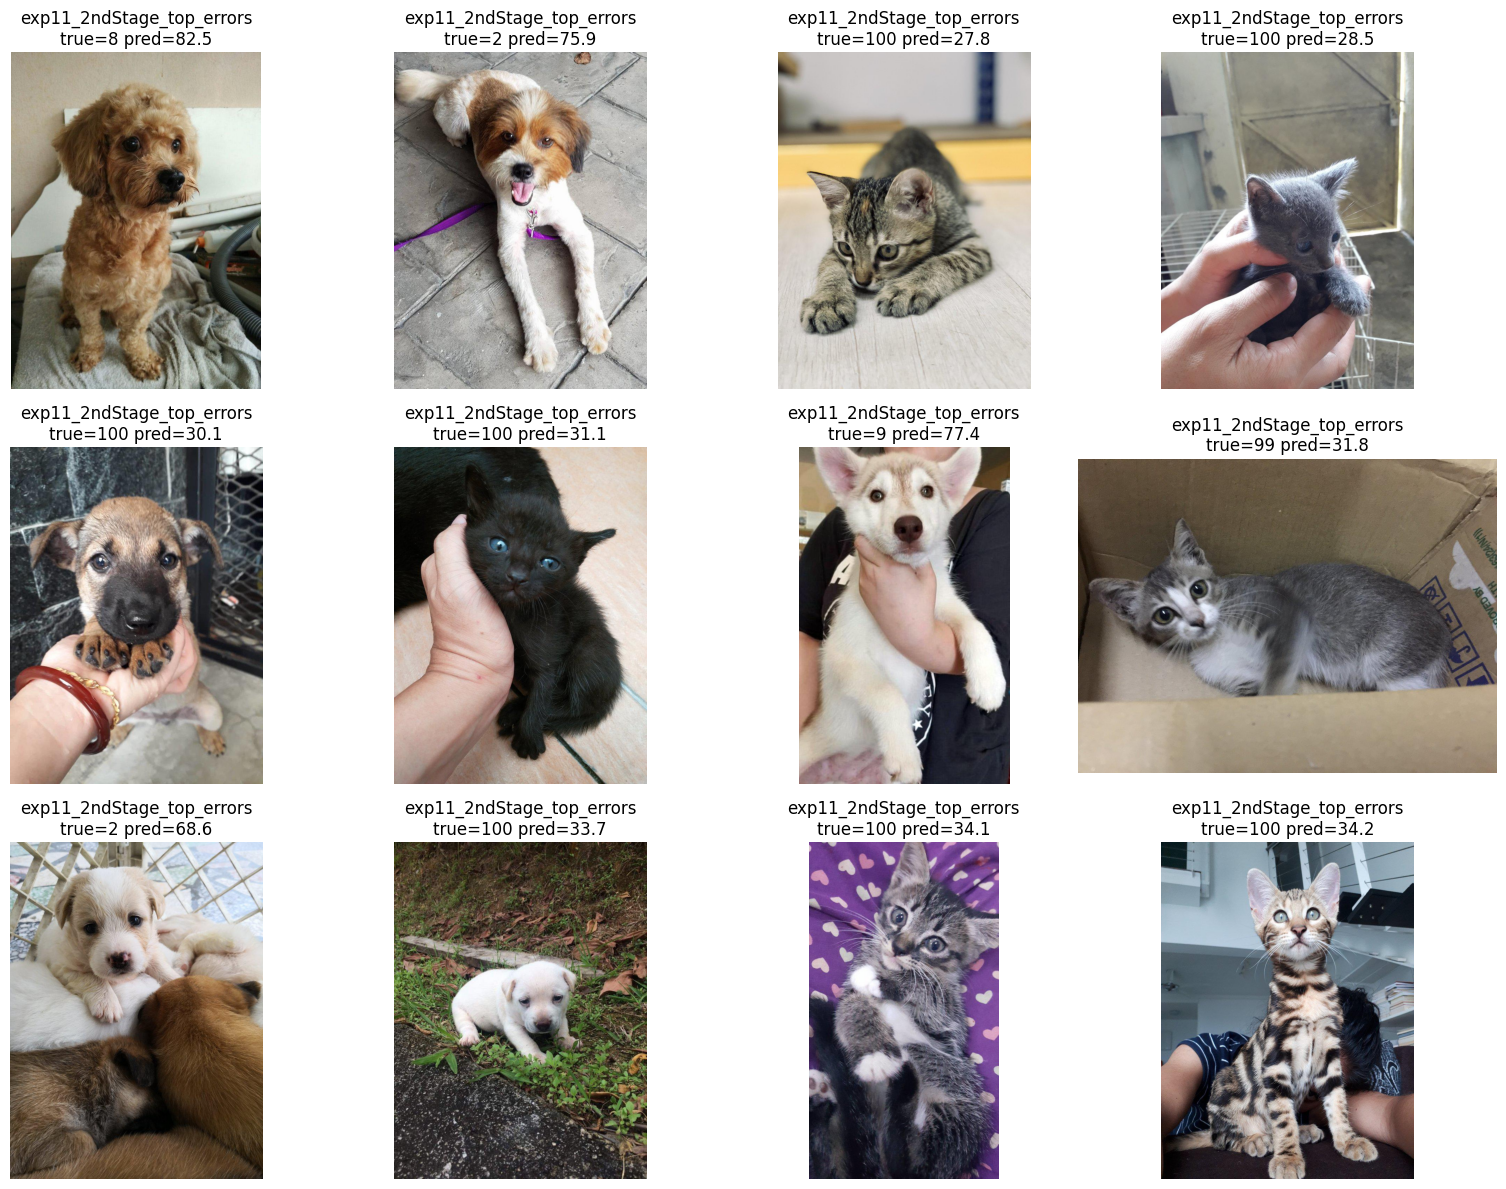

In [54]:
# Images of worst errors
from src.plot import show_images_grid
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(test_err_df, img_folder, n=12, title_prefix="exp11_2ndStage_top_errors",pred_col="pred_2ndStageSVR")

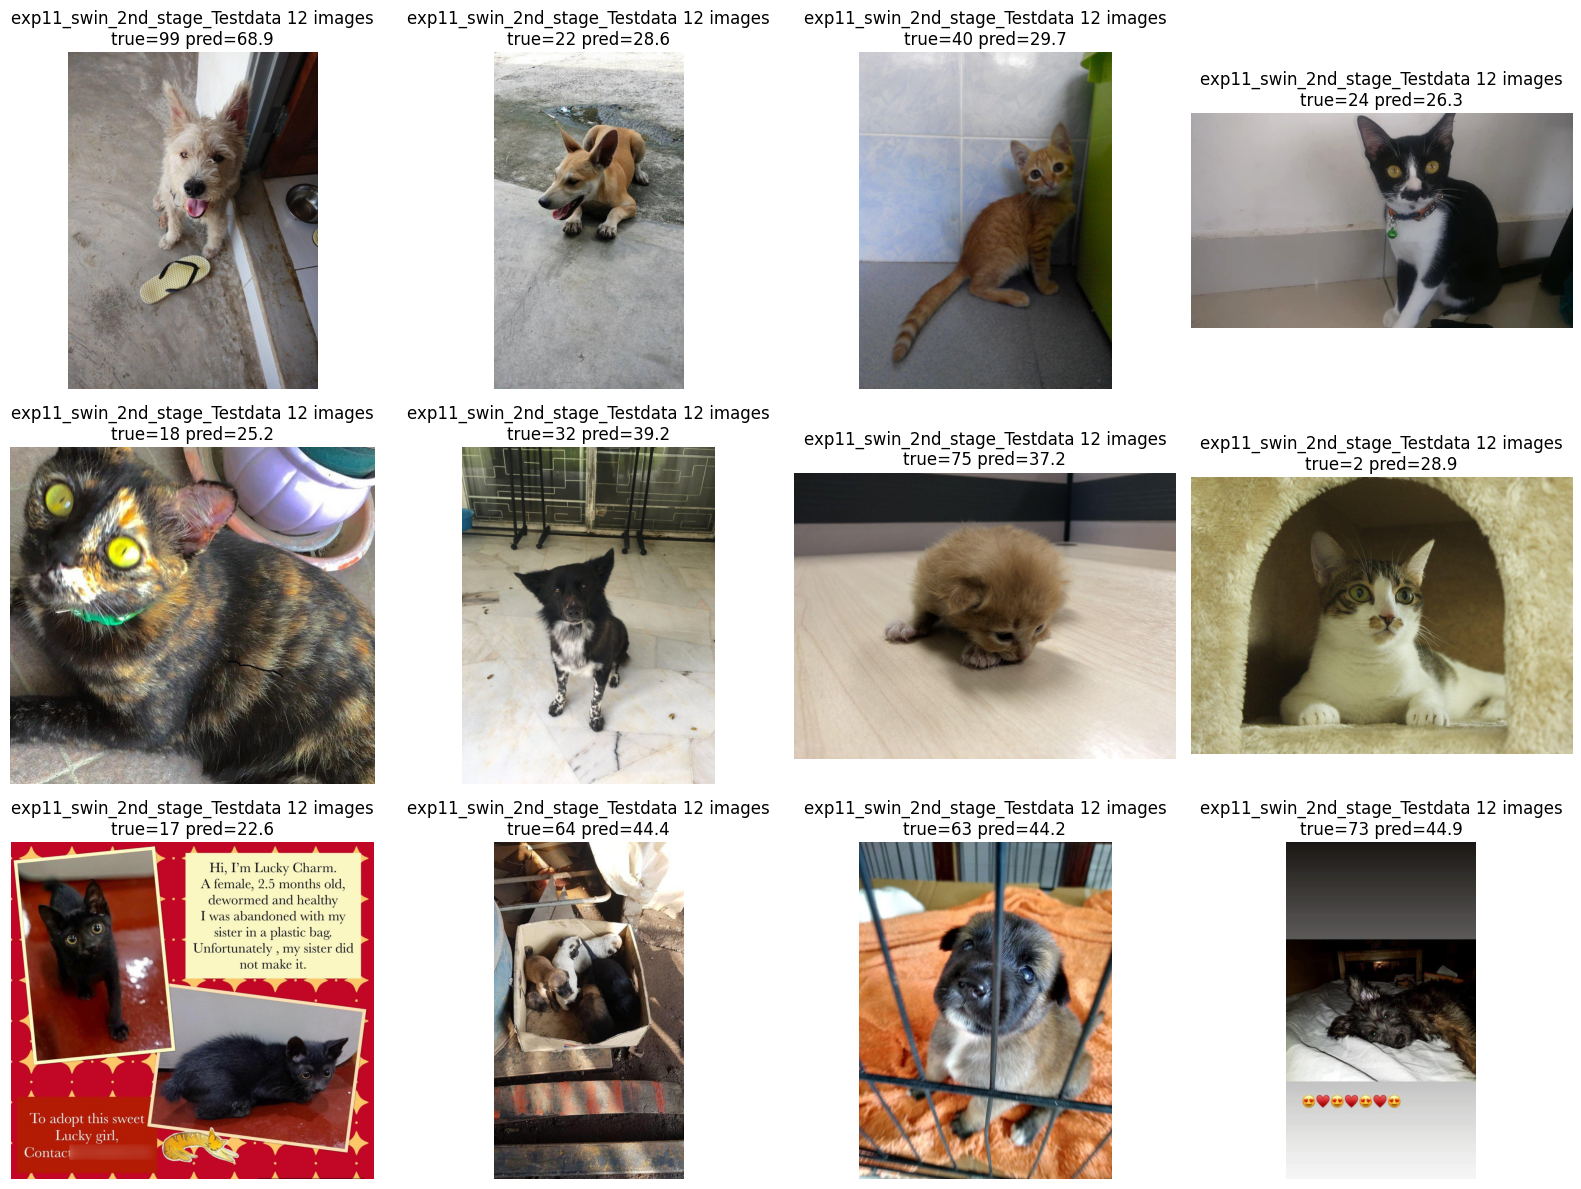

In [55]:
show_images_grid(test_df_pred, img_folder, n=12, pred_col="pred_2ndStageSVR", title_prefix="exp11_swin_2nd_stage_Testdata 12 images")